In [1]:
import pandas as pd

import numpy as np

path_to_csv = '../data/raw/ucs_satellites.txt'

Data_Frame = pd.read_csv(
    path_to_csv,
    sep='\t',
    encoding='latin-1',
    on_bad_lines='skip',
)

print("=" * 50)
print("Data Frame Info:")
print(f"Number of rows: {Data_Frame.shape[0]}", f"Number of columns: {Data_Frame.shape[1]}")
print(Data_Frame.head())
Data_Frame.info()

Data Frame Info:
Number of rows: 7562 Number of columns: 67
  Current Official Name of Satellite Country/Org of UN Registry  \
0                         1HOPSAT-TD                         NR   
1            AAC AIS-Sat1Ê(Kelpie 1)             United Kingdom   
2                            Aalto-1                    Finland   
3                              AAt-4                    Denmark   
4                              ABS-2                         NR   

  Country of Operator/Owner                 Operator/Owner       Users  \
0                       USA                   Hera Systems  Commercial   
1            United Kingdom                AAC Clyde Space  Commercial   
2                   Finland               Aalto University       Civil   
3                   Denmark          University of Aalborg       Civil   
4             Multinational  Asia Broadcast Satellite Ltd.  Commercial   

                  Purpose                       Detailed Purpose  \
0       Earth Observatio

## Que se puede observar aquí en primera instancia
1) tenemmos columnas fantasmas, como las Unamed: 27 
2) el tipo de datos que se han leido como object en lugar de float, por ejemplo: Period (minutes) entre otras
3) y tambien tenemos datos faltantes,así como el expected lifetime (yrs) que tiene nulos


## Que hago ahora?: 
Empesaría por revisar y buscar la fromade auditar esas primeras 27 columnas.
Pero a buen ojo, si nos fijamos justo despues de la 27 hay hasta la 35 otros valores de columnas, y en adelante la 36 y así osilan entre un 484 a 488 con filas de texto resiual es decir cas vacías. asi como la 27 más vacía aún

In [2]:
columnas_validas = Data_Frame.iloc[:,:36]

Data_Frame_reducido = columnas_validas.copy()

print("=" * 60)
print("Data Frame Reducido:")
print("Número de filas:", Data_Frame_reducido.shape[0], f"Número de columnas: {Data_Frame_reducido.shape[1]}")
print("=" * 60)

print("Últimas columnas de esta variable:")
print(Data_Frame_reducido.columns[-3:])

Data Frame Reducido:
Número de filas: 7562 Número de columnas: 36
Últimas columnas de esta variable:
Index(['Source.4', 'Source.5', 'Source.6'], dtype='object')


## Recordando la 27
Ahora que tengo eso recuredo que la 227 tambien es Unnamed y entonces la retiro igualmente de mi Data set

In [3]:
Data_Frame_reducido = Data_Frame_reducido.drop(columns = ['Unnamed: 27'])

print("=" * 60)
print("Columna Unnamed: 27 eliminada exitosamente:")
print("Número de filas:", Data_Frame_reducido.shape[0], f"Número de columnas: {Data_Frame_reducido.shape[1]}")
print("=" * 60)

columnas_entorno = list(Data_Frame_reducido.columns[25:29])
print(f"Columnas de la zona de interés: {columnas_entorno}")

Columna Unnamed: 27 eliminada exitosamente:
Número de filas: 7562 Número de columnas: 35
Columnas de la zona de interés: ['NORAD Number', 'Comments', 'Source Used for Orbital Data', 'Source']


# Reducido
Ahora he reducido el ancho de mi tabla desciendome de las columnas que no aportaban.

## En que me enfocaqría ahora?
Pues si me doy cuenta, hay ripos de dato que no coinciden con lo estipulado en el Data Set, por ejemplo el punto mas cercano a la tierra que dice estar en km o el punto mas lejano en km igual o el peso de los objetos al despegar que esta en kg, ya que son numéricos y me muestra en la primera exploración datos de tipo ojeti en lugar de float. Estos tres parametros seran nuestras primeras pruebas


In [4]:
print("Que tipo de datos tienen estas columnas?")
print(Data_Frame_reducido[['Perigee (km)','Apogee (km)','Launch Mass (kg.)']].dtypes)

print("Observación de los 10 primeros valores de estas columnas:")
print(Data_Frame_reducido[['Perigee (km)','Apogee (km)','Launch Mass (kg.)']].head(10))



Que tipo de datos tienen estas columnas?
Perigee (km)         object
Apogee (km)          object
Launch Mass (kg.)    object
dtype: object
Observación de los 10 primeros valores de estas columnas:
  Perigee (km) Apogee (km) Launch Mass (kg.)
0          566         576                22
1          637         654                 4
2          497         517                 5
3          442         687                 1
4       35,778      35,793             6,330
5       35,700      35,700             1,800
6       35,788      35,803             2,000
7       35,780      35,793             4,143
8       35,777      35,794             2,894
9          538         561                 9


## Los tipos de datos son:
Podemos observar que los tipos de datos son de tipo objeto, entre otrascosa que me pude dar cuenta, en el proceso de revision de los datos, fue que hay columnas que tienen como cabecera un punto despues de las unidades asi como hay unque tiene un espacio al iniciar, y las vamos a ir corrigiendo. sin embargo siendo objetivos y yendo riectamentes al grano de nuestros archivos podemos observar que los datos para estas columnas son numéicros con el pequeño detalle de que estan separados por comas, que Python entiende como si fueran formatos de texto, entonces eso sera lo que corregiremos.


In [5]:
Data_Frame_reducido.columns= Data_Frame_reducido.columns.str.strip()

print("Columnas después de eliminar espacios en blanco en las columnas:")
print(Data_Frame_reducido.columns)

Columnas después de eliminar espacios en blanco en las columnas:
Index(['Current Official Name of Satellite', 'Country/Org of UN Registry',
       'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose',
       'Detailed Purpose', 'Class of Orbit', 'Type of Orbit',
       'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)',
       'Eccentricity', 'Inclination (degrees)', 'Period (minutes)',
       'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)',
       'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor',
       'Country of Contractor', 'Launch Site', 'Launch Vehicle',
       'COSPAR Number', 'NORAD Number', 'Comments',
       'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2',
       'Source.3', 'Source.4', 'Source.5', 'Source.6'],
      dtype='object')


# ahora que 
hemos quitado los espacios de las columnas, vamos a corregor las comas

In [6]:
apogee_no_comas = Data_Frame_reducido['Apogee (km)'].astype(str).str.replace(',', '')
Data_Frame_reducido['Apogee (km)'] = pd.to_numeric(apogee_no_comas, errors='coerce')

mass_no_comas = Data_Frame_reducido['Launch Mass (kg.)'].astype(str).str.replace(',', '')
Data_Frame_reducido['Launch Mass (kg.)'] = pd.to_numeric(mass_no_comas, errors='coerce')

perigee_no_comas = Data_Frame_reducido['Perigee (km)'].astype(str).str.replace(',', '')
Data_Frame_reducido['Perigee (km)'] = pd.to_numeric(perigee_no_comas, errors='coerce')

print("Tipos de datos después del cambio:")
print(f"Perigee (km): {Data_Frame_reducido['Perigee (km)'].dtype}")
print(f"Apogee (km): {Data_Frame_reducido['Apogee (km)'].dtype}")
print(f"Launch Mass (kg.): {Data_Frame_reducido['Launch Mass (kg.)'].dtype}")

print(Data_Frame_reducido[['Perigee (km)','Apogee (km)','Launch Mass (kg.)']].describe())

Tipos de datos después del cambio:
Perigee (km): float64
Apogee (km): float64
Launch Mass (kg.): float64
       Perigee (km)    Apogee (km)  Launch Mass (kg.)
count   7553.000000    7553.000000        7315.000000
mean    3703.945187    4236.369390         626.323582
std     9715.789212   13123.003517        1386.207031
min      150.000000      49.000000           1.000000
25%      521.000000     536.000000         148.000000
50%      548.000000     561.000000         260.000000
75%      600.000000     626.000000         280.000000
max    62200.000000  353798.000000       22500.000000


## que se ve en principio?
en principio vemos como los datos, se han corregido las comas por puntos y desde ya se puede ir observando cositas, enterminos de un poco de ciencia, como en el APOGEE(punto de órbita más lejano a la tierra) el mínimo nos dice que está a 49km? super raro ya quee a esa altura un satélite se quemaría en la atmosfea. (Esto me puede decir que hay datos o corruptos o erroneos); además con la Mediana se ve como en el 50% de los objetos tiene un PRIGEE(punto de órbita más cercano a la tierra) de 548km y un APODEE(punto de órbita más lejano a la tierra) de 561km. Lo que nos diría que la mayoría de los satélites y basura espacial están concentrados en la Orbita Baja dTerrestre llamada LEO.
Ahrora tambien se ve  que en los maximos el objeto más pesado es de 22500kg lo que equivaldría a un autobus, así tambien el APOGEE llega a colocarse a 353798 km de distacia que esta practicamente casi por poco cerca a la distancia en PERIGEE de la luna a la tierra. (datos interesantes)

In [7]:
print(Data_Frame_reducido.head().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Current Official Name of Satellite  5 non-null      object 
 1   Country/Org of UN Registry          5 non-null      object 
 2   Country of Operator/Owner           5 non-null      object 
 3   Operator/Owner                      5 non-null      object 
 4   Users                               5 non-null      object 
 5   Purpose                             5 non-null      object 
 6   Detailed Purpose                    3 non-null      object 
 7   Class of Orbit                      5 non-null      object 
 8   Type of Orbit                       4 non-null      object 
 9   Longitude of GEO (degrees)          5 non-null      float64
 10  Perigee (km)                        5 non-null      float64
 11  Apogee (km)                         5 non-null   

## Atacar las columnas
Ahora, vamos a atacar a todas las columnas que presentan datos no correspondientes a su tipo


In [8]:
columnas_numéricas_a_tratar = [
    'Perigee (km)', 
    'Apogee (km)', 
    'Eccentricity', 
    'Inclination (degrees)', 
    'Launch Mass (kg.)',
    'Period (minutes)', 
    'Dry Mass (kg.)', 
    'Power (watts)'
]

for columnas in columnas_numéricas_a_tratar:
    cambio_comas = Data_Frame_reducido[columnas].astype(str).str.replace(',', '')
    Data_Frame_reducido[columnas] = pd.to_numeric(cambio_comas, errors='coerce')

Data_Frame_reducido['Date of Launch'] = pd.to_datetime(Data_Frame_reducido['Date of Launch'], errors='coerce')
Data_Frame_reducido['NORAD Number'] = Data_Frame_reducido['NORAD Number'].astype(str)
Data_Frame_reducido['COSPAR Number'] = Data_Frame_reducido['COSPAR Number'].astype(str)

#print(Data_Frame_reducido.info())

print("=" * 60)
print("Se ha realizado la conversion de las variables seleccionadas")
print("=" * 60)
print("\nVerificación de tipos de datos en el DataFrame Reducido:")
columnas_totales_a_tratar = columnas_numéricas_a_tratar + ['Date of Launch', 'NORAD Number', 'COSPAR Number']
print(Data_Frame_reducido[columnas_totales_a_tratar].dtypes)

print(Data_Frame_reducido.info())

Se ha realizado la conversion de las variables seleccionadas

Verificación de tipos de datos en el DataFrame Reducido:
Perigee (km)                    float64
Apogee (km)                     float64
Eccentricity                    float64
Inclination (degrees)           float64
Launch Mass (kg.)               float64
Period (minutes)                float64
Dry Mass (kg.)                  float64
Power (watts)                   float64
Date of Launch           datetime64[ns]
NORAD Number                     object
COSPAR Number                    object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7562 entries, 0 to 7561
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Current Official Name of Satellite  7560 non-null   object        
 1   Country/Org of UN Registry          7559 non-null   object        
 2   Country of Operator/Owner  

C:\Users\User\AppData\Local\Temp\ipykernel_30460\1274661147.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Data_Frame_reducido['Date of Launch'] = pd.to_datetime(Data_Frame_reducido['Date of Launch'], errors='coerce')


In [9]:
muestras_con_nulos = Data_Frame_reducido[Data_Frame_reducido['Dry Mass (kg.)'].isna()]

columnas_interes = [
    'Current Official Name of Satellite', 
    'Operator/Owner', 
    'Purpose', 
    'Launch Mass (kg.)', 
    'Dry Mass (kg.)', 
    'Power (watts)'
]

print("=== MUESTRA DE SATÉLITES CON DATOS FALTANTES ===")

print(muestras_con_nulos[columnas_interes].sample(10, random_state=42))

=== MUESTRA DE SATÉLITES CON DATOS FALTANTES ===
     Current Official Name of Satellite                        Operator/Owner  \
172                         Beidou 2-13  Chinese Ministry of National Defense   
5269                     Starlink-3833                                 SpaceX   
2954                       SpaceBEE-100                    Swarm Technologies   
3205                      Starlink-1169                                SpaceX   
2102                       OneWeb-0195                      OneWeb Satellites   
7470                     Yaogan 35-02C   Chinese Ministry of National Defense   
600                          Dove 4x-31                     Planet Labs, Inc.   
6688      Starlink-5574                                                SpaceX   
2373                       OneWeb-0504                      OneWeb Satellites   
5335                     Starlink-3899                                 SpaceX   

                            Purpose  Launch Mass (kg.)  Dry

In [11]:
import sys
import os


sys.path.append(os.path.abspath(os.path.join('..')))

from src.features import construccion_caracteristicas_de_satelites

# Aplicamos la función para generar las 3 nuevas columnas analíticas
Data_Frame_reducido = construccion_caracteristicas_de_satelites(Data_Frame_reducido)

print("=" * 60)
print("🚀 ¡INGENIERÍA DE CARACTERÍSTICAS COMPLETADA!")
print("=" * 60)
print("\nMuestra de las nuevas columnas generadas:")

# Verificamos los resultados de las nuevas variables con una muestra de control
columnas_nuevas = ['Current Official Name of Satellite', 'Age_In_Orbit_Years', 'Orbit_Class_Extended', 'Mass_Category']
print(Data_Frame_reducido[columnas_nuevas].head(10).to_string())

🚀 ¡INGENIERÍA DE CARACTERÍSTICAS COMPLETADA!

Muestra de las nuevas columnas generadas:
  Current Official Name of Satellite  Age_In_Orbit_Years Orbit_Class_Extended          Mass_Category
0                         1HOPSAT-TD                 7.0      LEO (Low Earth)   Lightweight (<500kg)
1            AAC AIS-Sat1Ê(Kelpie 1)                 3.0      LEO (Low Earth)   Lightweight (<500kg)
2                            Aalto-1                 9.0      LEO (Low Earth)   Lightweight (<500kg)
3                              AAt-4                10.0      LEO (Low Earth)   Lightweight (<500kg)
4                              ABS-2                12.0  GEO (Geostationary)  Heavyweight (>=500kg)
5                             ABS-2A                10.0  GEO (Geostationary)  Heavyweight (>=500kg)
6                             ABS-3A                11.0  GEO (Geostationary)  Heavyweight (>=500kg)
7                              ABS-4                22.0  GEO (Geostationary)  Heavyweight (>=500kg)
8  

In [12]:

ruta_procesada = '../data/processed/demo_clean_features.csv'

Data_Frame_reducido.to_csv(ruta_procesada, index=False)

print("=" * 60)
print(f"Proceso de exportación completado exitosamente")
print(f"Ubicación: {ruta_procesada}")
print("=" * 60)

Proceso de exportación completado exitosamente
Ubicación: ../data/processed/demo_clean_features.csv


C:\Users\User\AppData\Local\Temp\ipykernel_30460\3757661833.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(


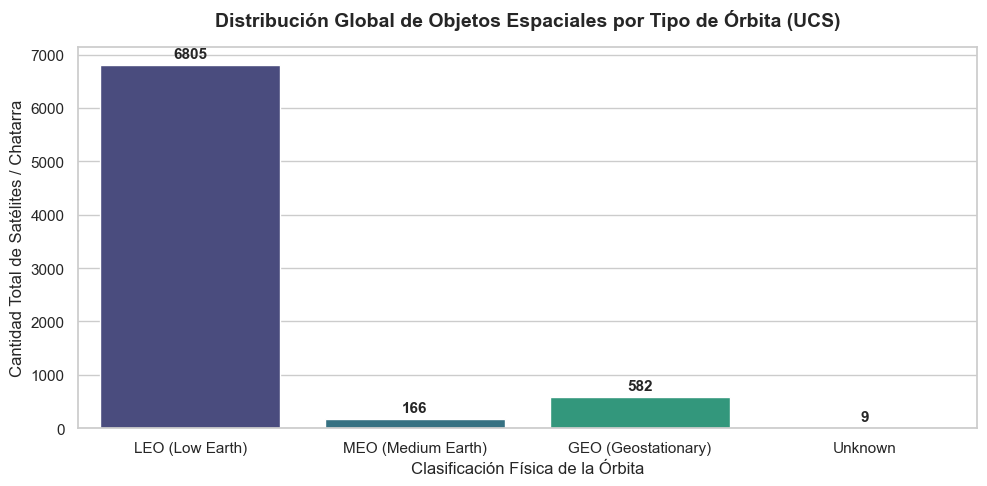

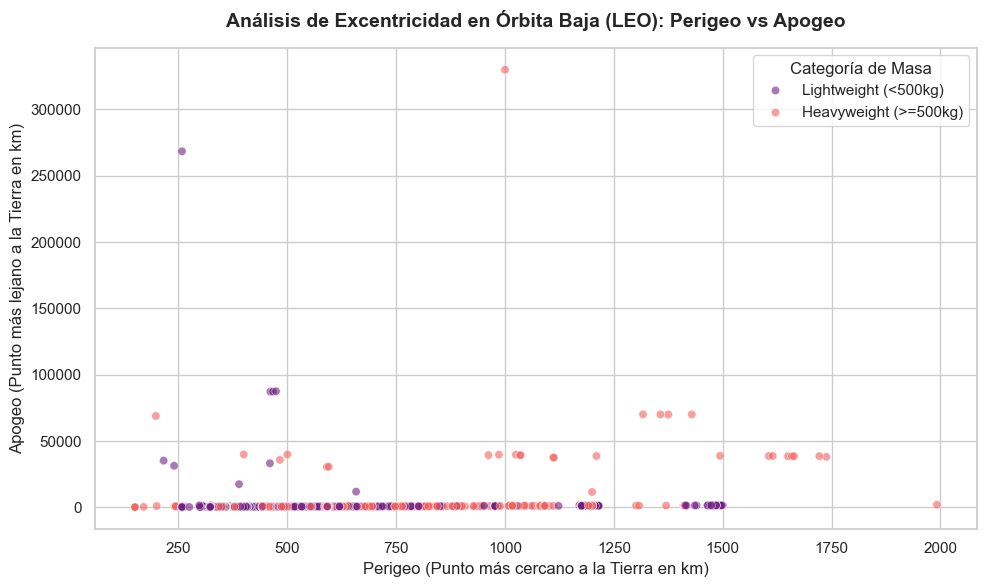

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta_procesada = '../data/processed/demo_clean_features.csv'
df_analisis = pd.read_csv(ruta_procesada)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

plt.figure(figsize=(10, 5))
ax1 = sns.countplot(
    data=df_analisis, 
    x='Orbit_Class_Extended', 
    palette='viridis', 
    order=['LEO (Low Earth)', 'MEO (Medium Earth)', 'GEO (Geostationary)', 'Unknown']
)

plt.title('Distribución Global de Objetos Espaciales por Tipo de Órbita (UCS)', pad=15, fontweight='bold')
plt.xlabel('Clasificación Física de la Órbita')
plt.ylabel('Cantidad Total de Satélites / Chatarra')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

df_leo = df_analisis[df_analisis['Perigee (km)'] < 2000]

sns.scatterplot(
    data=df_leo, 
    x='Perigee (km)', 
    y='Apogee (km)', 
    hue='Mass_Category', 
    palette='magma', 
    alpha=0.6
)

plt.title('Análisis de Excentricidad en Órbita Baja (LEO): Perigeo vs Apogeo', pad=15, fontweight='bold')
plt.xlabel('Perigeo (Punto más cercano a la Tierra en km)')
plt.ylabel('Apogeo (Punto más lejano a la Tierra en km)')
plt.legend(title='Categoría de Masa')

plt.tight_layout()
plt.show()

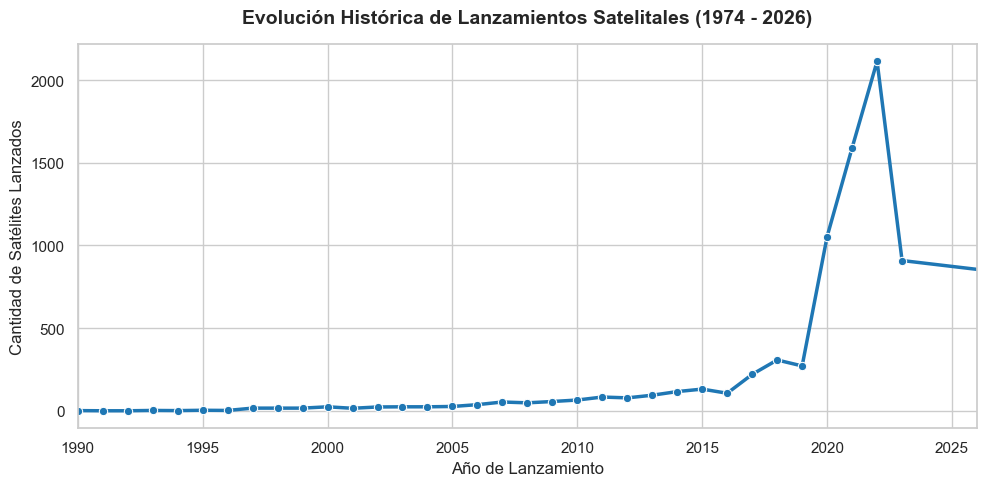

C:\Users\User\AppData\Local\Temp\ipykernel_30460\1316597483.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(


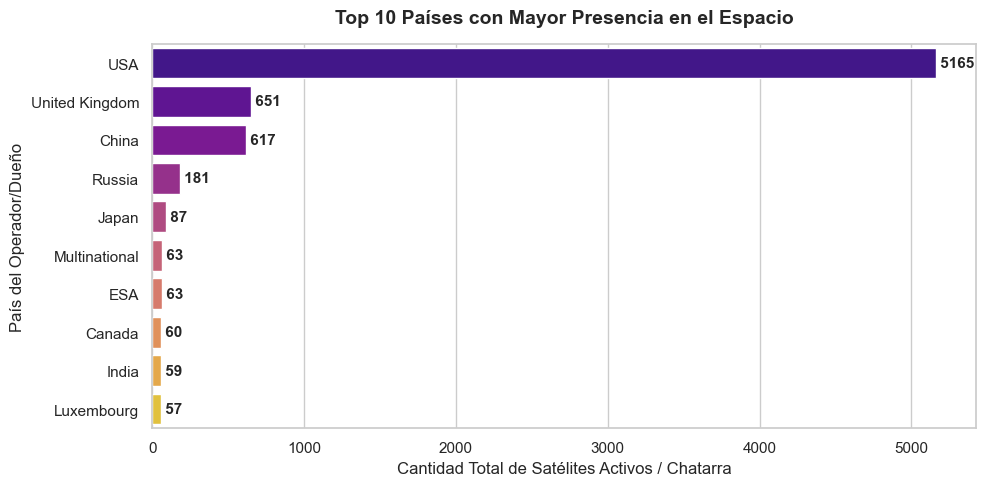

In [14]:
# ==============================================================================
# GRÁFICO 3: Evolución Histórica de los Lanzamientos (Línea de Tiempo)
# Intención: Identificar el punto de inflexión del "Boom" Aeroespacial Comercial.
# ==============================================================================
plt.figure(figsize=(10, 5))

# Extraemos el año de la columna Date of Launch que limpiamos ayer
df_analisis['Launch_Year'] = pd.to_datetime(df_analisis['Date of Launch']).dt.year

# Agrupamos por año y contamos cuántos satélites se lanzaron
lanzamientos_por_anio = df_analisis.groupby('Launch_Year').size()

sns.lineplot(
    x=lanzamientos_por_anio.index, 
    y=lanzamientos_por_anio.values, 
    color='#1f77b4', 
    linewidth=2.5,
    marker='o',
    markersize=6
)

plt.title('Evolución Histórica de Lanzamientos Satelitales (1974 - 2026)', pad=15, fontweight='bold')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Satélites Lanzados')
plt.xlim(1990, 2026) # Nos enfocamos desde 1990 para ver el cambio moderno con claridad
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 4: Top 10 Países / Organizaciones Propietarias de Satélites
# Intención: Revelar el control y dominio geopolítico del espacio exterior.
# ==============================================================================
plt.figure(figsize=(10, 5))

top_paises = df_analisis['Country of Operator/Owner'].value_counts().head(10)

ax4 = sns.barplot(
    x=top_paises.values, 
    y=top_paises.index, 
    palette='plasma'
)

plt.title('Top 10 Países con Mayor Presencia en el Espacio', pad=15, fontweight='bold')
plt.xlabel('Cantidad Total de Satélites Activos / Chatarra')
plt.ylabel('País del Operador/Dueño')

# Añadimos los valores al final de cada barra horizontal
for index, value in enumerate(top_paises.values):
    plt.text(value, index, f' {int(value)}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()